# LumenY — Signed MFE Direction Model (1H) — All 15 Pairs

Trains Q25/Q50/Q75 quantile regression on **signed MFE**:
```
signed_mfe = mfe_long_pips - mfe_short_pips
```
- Positive → long move dominated
- Negative → short move dominated
- `sign(Q50)` → predicted direction
- `|Q50|` → confidence / expected pip magnitude

Threshold: trade when `|Q50| > X` (same gate logic as mfe_max model)

In [17]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import joblib
import warnings
import gc
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.metrics import mean_pinball_loss

FEATURES_DIR = Path("../backend/data/features_9")
MODELS_DIR   = Path("../backend/models_9/signed_mfe")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

QUANTILES      = [0.25, 0.50, 0.75]
QUANTILE_NAMES = ["Q25", "Q50", "Q75"]

# -- CRITICAL: Training cutoff --
TRAIN_END  = "2024-06-30"
AVG_SPREAD = 0.00028

print("Ready.")
print(f"Model to train: Q25/Q50/Q75 quantile regression on signed MFE")
print(f"Target: signed_mfe = mfe_long_pips - mfe_short_pips")
print(f"Training cutoff: {TRAIN_END}")


Ready.
Model to train: Q50 median regression on MFE (max favorable excursion)
Training cutoff: 2024-06-30


## 1. Load Microstructure Dataset

In [18]:
# Load features_9 (all 15 pairs)
dfs = []
for f in sorted(FEATURES_DIR.glob('*_features.parquet')):
    tmp = pd.read_parquet(f)
    dfs.append(tmp)

df_features = pd.concat(dfs).sort_index()
del dfs
print(f'features_9: {df_features.shape}')

# Load labels from features_2 (majors) + features_3 (crosses)
df_labels_maj = pd.read_parquet(Path('../backend/data/features_2') / 'all_pairs_microstructure.parquet')[['pair', 'label_1H', 'label_4H']]
df_labels_cro = pd.read_parquet(Path('../backend/data/features_3') / 'all_pairs_microstructure.parquet')[['pair', 'label_1H', 'label_4H']]
df_labels = pd.concat([df_labels_maj, df_labels_cro]).sort_index()
del df_labels_maj, df_labels_cro
print(f'labels:     {df_labels.shape}')

# Join on (timestamp index + pair) to avoid cartesian product
df_features = df_features.reset_index()
df_labels   = df_labels.reset_index()
df = pd.merge(df_features, df_labels, on=[df_features.columns[0], 'pair'], how='inner')
df = df.set_index(df.columns[0]).sort_index()
del df_features, df_labels
print(f'merged:     {df.shape}')

# Signed MFE: positive = long dominated, negative = short dominated
df['signed_mfe'] = df['mfe_long_pips'] - df['mfe_short_pips']

label_cols   = [c for c in df.columns if c.startswith('label_')] + ['mfe_long_pips', 'mfe_short_pips', 'mfe_max', 'signed_mfe']
drop_cols    = label_cols + ['pair', 'trail_long_bars', 'trail_short_bars', 'trail_stop_pips', 'mfe_atr_24']
feature_cols = [c for c in df.columns if c not in drop_cols]

TARGET_COL = 'signed_mfe'

# Split
df_train = df[df.index <= TRAIN_END].copy()
df_test  = df[df.index > TRAIN_END].copy()

print(f'\nFull dataset:  {df.shape}  ({df.index.min().date()} to {df.index.max().date()})')
print(f'Features:      {len(feature_cols)} (hour_sin/cos excluded)')
print(f'Train set:     {len(df_train):,} rows  ({df_train.index.min().date()} to {df_train.index.max().date()})')
print(f'Test set:      {len(df_test):,} rows  ({df_test.index.min().date()} to {df_test.index.max().date()})')
print(f'All pairs:     {sorted(df["pair"].unique())}')
print(f'\nTarget stats (train):')
print(df_train[TARGET_COL].describe())

features_9: (1518020, 327)
labels:     (1518020, 3)
merged:     (1518020, 329)

Full dataset:  (1518020, 330)  (2009-09-25 to 2025-12-31)
Features:      320 (hour_sin/cos excluded)
Train set:     1,378,758 rows  (2009-09-25 to 2024-06-28)
Test set:      139,262 rows  (2024-06-30 to 2025-12-31)
All pairs:     ['AUDJPY', 'AUDNZD', 'AUDUSD', 'CADJPY', 'CHFJPY', 'EURAUD', 'EURGBP', 'EURJPY', 'EURUSD', 'GBPJPY', 'GBPUSD', 'NZDUSD', 'USDCAD', 'USDCHF', 'USDJPY']

Target stats (train):
count    1.335153e+06
mean     4.258549e+01
std      5.414837e+01
min      2.500000e+00
25%      2.200000e+01
50%      3.290000e+01
75%      5.060000e+01
max      1.013354e+04
Name: mfe_max, dtype: float64


## 2. Walk-Forward Splits

In [19]:
def walk_forward_splits(n, n_splits=5, test_ratio=0.1):
    """Expanding window walk-forward splits. All within training data."""
    test_size = int(n * test_ratio)
    splits = []
    for i in range(n_splits):
        test_start = int(n * 0.5) + i * (int(n * 0.5) // n_splits)
        test_end   = test_start + test_size
        if test_end > n:
            break
        splits.append((list(range(0, test_start)), list(range(test_start, test_end))))
    return splits

splits = walk_forward_splits(len(df_train))
print(f'Walk-forward splits: {len(splits)} (all within training set, before {TRAIN_END})')
for i, (train_idx, test_idx) in enumerate(splits):
    print(f'  Fold {i+1}: Train -> {df_train.index[train_idx[-1]].date()} ({len(train_idx):,}) | '
          f'Test {df_train.index[test_idx[0]].date()} -> {df_train.index[test_idx[-1]].date()} ({len(test_idx):,})')

Walk-forward splits: 5 (all within training set, before 2024-06-30)
  Fold 1: Train -> 2017-02-28 (689,379) | Test 2017-02-28 -> 2018-08-21 (137,875)
  Fold 2: Train -> 2018-08-21 (827,254) | Test 2018-08-21 -> 2020-02-20 (137,875)
  Fold 3: Train -> 2020-02-20 (965,129) | Test 2020-02-20 -> 2021-08-25 (137,875)
  Fold 4: Train -> 2021-08-25 (1,103,004) | Test 2021-08-25 -> 2023-01-25 (137,875)
  Fold 5: Train -> 2023-01-25 (1,240,879) | Test 2023-01-25 -> 2024-06-28 (137,875)


## 3. LightGBM Quantile Config

In [20]:
def get_lgbm_params(quantile):
    return {
        'objective':         'quantile',
        'alpha':             quantile,
        'metric':            'quantile',
        'boosting_type':     'gbdt',
        'n_estimators':      5000,
        'learning_rate':     0.02,
        'num_leaves':        64,
        'max_depth':         6,
        'min_child_samples': 50,
        'feature_fraction':  0.7,
        'bagging_fraction':  0.8,
        'bagging_freq':      5,
        'reg_alpha':         0.1,
        'reg_lambda':        0.1,
        'random_state':      42,
        'n_jobs':            -1,
        'verbose':           -1,
        'device':            'gpu',
    }

print('Params ready. objective=quantile with pinball loss.')

Params ready. objective=quantile with pinball loss.


## 4. Train 3 Quantile Models (Walk-Forward CV + Final)

In [21]:
y_all = df_train[TARGET_COL]
valid_mask = y_all.notna()
X_clean = df_train[feature_cols][valid_mask].ffill().fillna(0)
y_clean = y_all[valid_mask]

print(f'Training samples: {len(X_clean):,} (all before {TRAIN_END})')
print(f'Target mean: {y_clean.mean():.6f}, std: {y_clean.std():.6f}')

splits = walk_forward_splits(len(X_clean))
oof_preds  = {q: np.full(len(X_clean), np.nan) for q in QUANTILES}
best_iters = {q: [] for q in QUANTILES}
cv_pinball = {q: [] for q in QUANTILES}

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f'\nTraining {q_name} (alpha={q})...')
    params = get_lgbm_params(q)

    for fold, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X_clean.iloc[train_idx], y_clean.iloc[train_idx]
        X_te, y_te = X_clean.iloc[test_idx], y_clean.iloc[test_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)],
                  callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

        preds = model.predict(X_te)
        oof_preds[q][test_idx] = preds
        cv_pinball[q].append(mean_pinball_loss(y_te, preds, alpha=q))
        best_iters[q].append(model.best_iteration_)

    print(f'  CV Pinball: {np.mean(cv_pinball[q]):.6f} | Best iters: {best_iters[q]}')
    del model; gc.collect()

# Train final models on ALL training data
print(f'\n{"="*55}')
print('Training final models on full training set...')
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    avg_iter = max(50, int(np.mean(best_iters[q])))
    params = get_lgbm_params(q)
    final_model = lgb.LGBMRegressor(**{**params, 'n_estimators': avg_iter})
    final_model.fit(X_clean, y_clean)

    q_int = int(q * 100)
    joblib.dump({
        'model': final_model,
        'quantile': q,
        'horizon': '1H',
        'feature_cols': feature_cols,
        'train_end': TRAIN_END,
        'avg_spread': AVG_SPREAD,
        'cv_pinball': np.mean(cv_pinball[q]),
        'n_iters': avg_iter,
    }, MODELS_DIR / f'model_1H_Q{q_int}.joblib')

    size_mb = (MODELS_DIR / f'model_1H_Q{q_int}.joblib').stat().st_size / 1024 / 1024
    print(f'  {q_name}: {avg_iter} iters, pinball={np.mean(cv_pinball[q]):.6f}, saved ({size_mb:.1f} MB)')
    del final_model; gc.collect()

print(f'\nAll 3 models saved to {MODELS_DIR}')

Training samples: 1,335,153 (all before 2024-06-30)
Target mean: 42.585491, std: 54.148373

Training Q50 (alpha=0.5)...
  CV Pinball: 8.150109 | Best iters: [320, 320, 321, 569, 585]

Training final models on full training set...
  Q50: 423 iters, pinball=8.150109, saved (2.4 MB)

All 3 models saved to ..\backend\models_9\mfe_q50


## 5. Quantile Coverage (OOF Calibration)

OOF Quantile Coverage:
Quantile   Target     Actual     Gap
------------------------------------------
Q50        0.50       0.507      +0.007  OK


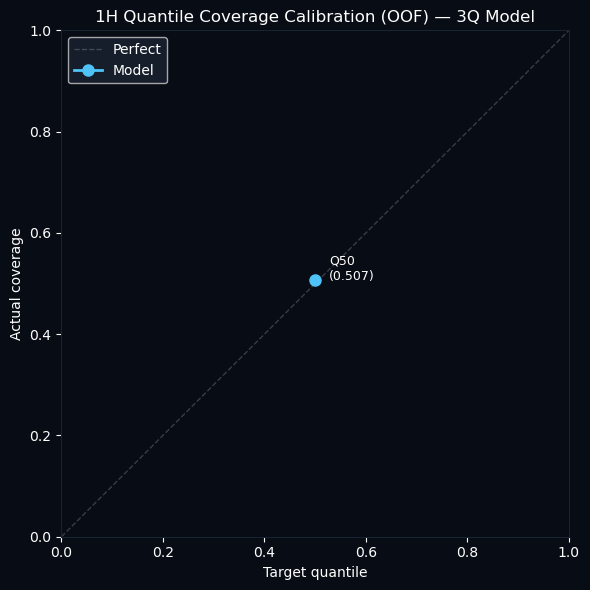

In [22]:
valid_oof = ~np.isnan(oof_preds[QUANTILES[0]])
y_oof = y_clean.values[valid_oof]

print(f'OOF Quantile Coverage:')
print(f'{"Quantile":<10} {"Target":<10} {"Actual":<10} {"Gap"}')
print(f'{"-"*42}')

for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    preds_oof = oof_preds[q][valid_oof]
    coverage  = np.mean(y_oof <= preds_oof)
    gap       = coverage - q
    flag      = 'OK' if abs(gap) < 0.03 else 'NEEDS CALIBRATION'
    print(f'{q_name:<10} {q:<10.2f} {coverage:<10.3f} {gap:+.3f}  {flag}')

# Calibration plot
fig, ax = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

targets = QUANTILES
actuals = [np.mean(y_oof <= oof_preds[q][valid_oof]) for q in QUANTILES]

ax.plot([0,1], [0,1], '--', color=(1,1,1,0.2), linewidth=1, label='Perfect')
ax.plot(targets, actuals, 'o-', color='#4fc3f7', linewidth=2, markersize=8, label='Model')
for t, a, name in zip(targets, actuals, QUANTILE_NAMES):
    ax.annotate(f'{name}\n({a:.3f})', (t, a), textcoords='offset points',
                xytext=(10, 0), color='white', fontsize=9)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Target quantile', color='white')
ax.set_ylabel('Actual coverage', color='white')
ax.set_title('1H Quantile Coverage Calibration (OOF) â€” 3Q Model', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2332', labelcolor='white')
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')
plt.tight_layout()
plt.show()

## 6. Test Set Evaluation

Load final models, predict all 3 quantiles on unseen test set.

**Trading rules:**
- Direction = sign(Q50)
- Trade only when |Q50| > spread
- PnL per trade = direction Ã— actual_return - spread

In [25]:
# -- Prepare test data --
X_test = df_test[feature_cols].ffill().fillna(0)
y_test = df_test[TARGET_COL]
valid_test = y_test.notna()
X_test_clean = X_test[valid_test]
y_test_clean = y_test[valid_test]

# -- Predict all 3 quantiles --
preds = {}
for q, qname in zip(QUANTILES, QUANTILE_NAMES):
    bundle = joblib.load(MODELS_DIR / f"model_1H_{qname}.joblib")
    preds[qname] = bundle["model"].predict(X_test_clean)
    print(f"{qname}: mean={preds[qname].mean():.4f}, std={preds[qname].std():.4f}")

# -- Build results DataFrame --
results = pd.DataFrame({
    "actual":    y_test_clean.values,
    "Q25":       preds["Q25"],
    "Q50":       preds["Q50"],
    "Q75":       preds["Q75"],
    "pair":      df_test.loc[valid_test, "pair"].values,
}, index=y_test_clean.index)

results["abs_q50"]   = results["Q50"].abs()
results["pred_dir"]  = np.sign(results["Q50"])   # +1=long, -1=short
results["actual_dir"] = np.sign(results["actual"])
results["correct"]   = (results["pred_dir"] == results["actual_dir"]).astype(int)

print(f"\nTest set: {len(results):,} rows ({results.index.min().date()} -> {results.index.max().date()})")
print(f"Actual signed_mfe — mean: {results['actual'].mean():.3f}  std: {results['actual'].std():.3f}")
print(f"Overall direction accuracy: {results['correct'].mean():.3f}")

# -- Direction accuracy at different |Q50| thresholds --
from sklearn.metrics import mean_absolute_error
print(f"\n{'|Q50| thresh':>14} {'Trades':>8} {'% kept':>7} {'Dir Acc':>9} {'Avg|actual|':>12} {'Avg|Q50|':>10} {'Long%':>7}")
print("-" * 75)
for thresh in [0, 10, 20, 30, 40, 50, 70, 100]:
    mask = results["abs_q50"] > thresh
    if mask.sum() < 50: continue
    s = results[mask]
    print(f"{thresh:>14} {mask.sum():>8,} {mask.mean():>7.1%} {s['correct'].mean():>9.3f} "
          f"{s['actual'].abs().mean():>12.1f} {s['abs_q50'].mean():>10.1f} {(s['pred_dir']==1).mean():>7.1%}")

# -- Per-pair breakdown --
print(f"\n{'Pair':>10} {'N':>6} {'Dir Acc':>9} {'Avg|actual|':>12} {'Long%':>7}")
print("-" * 50)
for pair, g in results.groupby("pair"):
    if len(g) < 10: continue
    print(f"{pair:>10} {len(g):>6,} {g['correct'].mean():>9.3f} "
          f"{g['actual'].abs().mean():>12.1f} {(g['pred_dir']==1).mean():>7.1%}")


Q50: mean=44.116776, std=26.676259

Test set: 136,372 rows (2024-07-01 -> 2025-12-31)
Actual MFE â€” mean: 59.51585  std: 95.00935

  Q50 threshold   Trades  % kept        MAE     corr   avg actual     avg pred
--------------------------------------------------------------------------------
         0.0000  136,372  100.0%   26.99713    0.466     59.51585     44.11678
        10.0000  136,372  100.0%   26.99713    0.466     59.51585     44.11678
        20.0000  126,072   92.4%   28.47484    0.456     62.59094     46.25430
        30.0000   88,472   64.9%   34.87902    0.431     75.85206     55.35898
        40.0000   60,802   44.6%   41.35356    0.441     89.18619     64.69035
        50.0000   40,695   29.8%   49.97077    0.426    105.06853     74.50803
        70.0000   15,748   11.5%   76.56993    0.395    151.14420     99.81325
       100.0000    5,182    3.8%  119.35128    0.387    221.99905    138.32706

Spread cost: 0.00028
Higher Q50 threshold = model only selects bars it pred

In [27]:
# -- Per-pair breakdown (Q50 > 30 pips filter) --
filtered = results[results['Q50'] > 30]

print(f'Per-pair results (Q50 > 30 pips):')
print(f'\n{"Pair":<10} {"Trades":>8} {"Avg MFE actual":>16} {"Avg MFE pred":>14} {"corr":>8}')
print('-' * 60)

for pair in sorted(filtered['pair'].unique()):
    p = filtered[filtered['pair'] == pair]
    corr = np.corrcoef(p['actual_mfe'], p['Q50'])[0, 1] if len(p) > 10 else 0
    print(f'{pair:<10} {len(p):>8,} {p["actual_mfe"].mean():>16.2f} {p["Q50"].mean():>14.2f} {corr:>8.3f}')

Per-pair results (Q50 > 30 pips):

Pair         Trades   Avg MFE actual   Avg MFE pred     corr
------------------------------------------------------------
AUDJPY        7,778            63.41          50.39    0.507
AUDNZD        9,063            85.43          50.23    0.413
AUDUSD        1,643            55.14          42.96    0.302
CADJPY        7,577            74.40          52.90    0.475
CHFJPY        9,116           123.15          80.20    0.538
EURAUD        9,118            82.94          59.60    0.382
EURGBP        1,220            92.33          46.48    0.474
EURJPY        8,934            66.17          55.77    0.365
EURUSD        3,037            45.96          39.21    0.384
GBPJPY        9,012            75.71          67.45    0.595
GBPUSD        5,333            43.52          38.48    0.357
NZDUSD        2,257           101.08          48.41    0.299
USDCAD        3,799            75.91          47.47    0.259
USDCHF        1,960            52.88          43.3

## 7. Equity Curves

In [28]:
# MFE lift by Q50 decile
results['q50_decile'] = pd.qcut(results['Q50'], q=10, labels=False, duplicates='drop')
decile_stats = results.groupby('q50_decile').agg(
    trades=('actual_mfe', 'count'),
    avg_actual_mfe=('actual_mfe', 'mean'),
    avg_pred_mfe=('Q50', 'mean')
).reset_index()

print(f'{"Decile":>8} {"Trades":>8} {"Avg Pred MFE":>14} {"Avg Actual MFE":>16}')
print('-' * 50)
for _, row in decile_stats.iterrows():
    bar = '#' * int(row.avg_actual_mfe / 5)
    print(f'{int(row.q50_decile):>8} {int(row.trades):>8} {row.avg_pred_mfe:>14.1f} {row.avg_actual_mfe:>16.1f}  {bar}')
print('\nDecile 0 = lowest predicted MFE, Decile 9 = highest')

  Decile   Trades   Avg Pred MFE   Avg Actual MFE
--------------------------------------------------
       0    13638           18.6             22.7  ####
       1    13637           22.6             27.0  #####
       2    13637           26.0             33.5  ######
       3    13637           30.0             39.8  #######
       4    13637           34.7             46.2  #########
       5    13637           39.8             52.6  ##########
       6    13637           46.3             58.8  ###########
       7    13637           53.9             69.8  #############
       8    13637           65.0             86.1  #################
       9    13638          104.2            158.6  ###############################

Decile 0 = lowest predicted MFE, Decile 9 = highest


## 8. Feature Importance

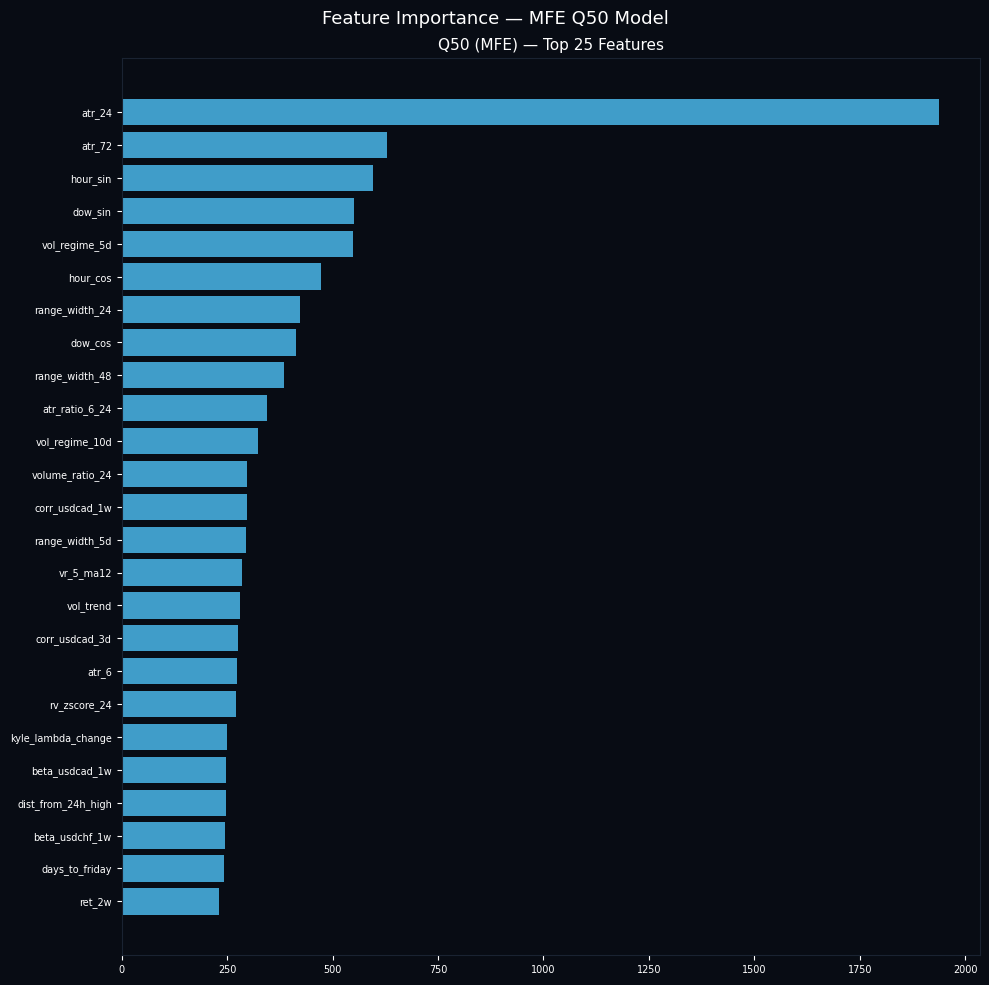

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
fig.patch.set_facecolor('#080c14')
ax.set_facecolor('#080c14')

bundle = joblib.load(MODELS_DIR / 'model_1H_Q50.joblib')
importance = pd.Series(bundle['model'].feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=True).tail(25)

ax.barh(importance.index, importance.values, color='#4fc3f7', alpha=0.8)
ax.tick_params(colors='white', labelsize=7)
ax.set_title('Q50 (MFE) â€” Top 25 Features', color='white', fontsize=11)
for spine in ax.spines.values(): spine.set_edgecolor('#1a2332')

plt.suptitle('Feature Importance â€” MFE Q50 Model', color='white', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Diagnostics

Q50 coverage: 0.512 (target: 0.50)
Mean actual MFE: 59.52 pips
Mean pred  MFE: 44.12 pips
Overall corr:   0.466


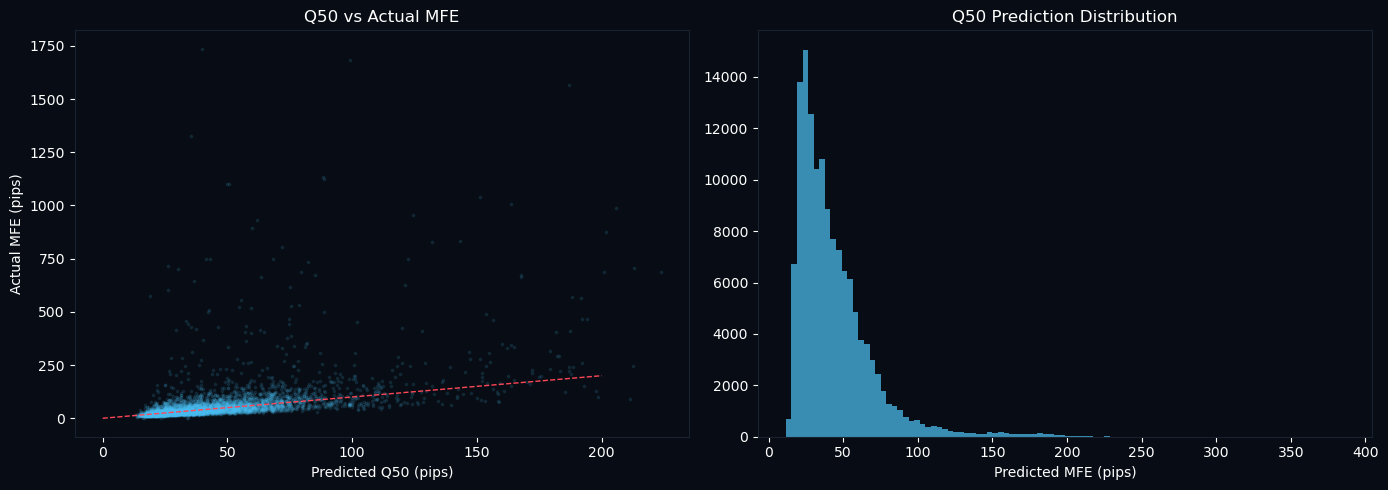

In [30]:
# Quantile coverage check
for q, qname in zip(QUANTILES, QUANTILE_NAMES):
    coverage = (results["actual"] <= results[qname]).mean()
    print(f"{qname} coverage: {coverage:.3f} (target: {q:.2f})")

print(f"\nOverall direction accuracy: {results['correct'].mean():.3f}")

# Scatter: Q50 vs actual signed_mfe
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#080c14")
for ax in axes:
    ax.set_facecolor("#080c14")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#1a2332")

sample = results.sample(min(5000, len(results)), random_state=42)
axes[0].scatter(sample["Q50"], sample["actual"], alpha=0.1, s=3, color="#4fc3f7")
axes[0].axhline(0, color="#ff4757", linewidth=0.8, linestyle="--")
axes[0].axvline(0, color="#ff4757", linewidth=0.8, linestyle="--")
axes[0].set_title("Q50 vs Actual signed_mfe", color="white")
axes[0].set_xlabel("Predicted Q50 (pips)", color="white")
axes[0].set_ylabel("Actual signed_mfe (pips)", color="white")

axes[1].hist(results["Q50"], bins=100, color="#4fc3f7", alpha=0.7, edgecolor="none")
axes[1].axvline(0, color="#ff4757", linewidth=1, linestyle="--")
axes[1].set_title("Q50 Prediction Distribution", color="white")
axes[1].set_xlabel("Predicted signed_mfe (pips)", color="white")

plt.tight_layout()
plt.show()


## 11. Summary

In [31]:
print("=" * 70)
print("SIGNED MFE MODEL — TRAINING COMPLETE")
print("=" * 70)

print(f"\nModels saved to: {MODELS_DIR.resolve()}")
for f in sorted(MODELS_DIR.glob("*.joblib")):
    print(f"  {f.name:<25} {f.stat().st_size / 1024 / 1024:.1f} MB")

print(f"\n-- CV Results --")
for q, q_name in zip(QUANTILES, QUANTILE_NAMES):
    print(f"  {q_name}: pinball={np.mean(cv_pinball[q]):.6f}, avg_iters={int(np.mean(best_iters[q]))}")

print(f"\n-- Test Set Results (UNSEEN, after {TRAIN_END}) --")
print(f"  Direction accuracy (all bars):  {results['correct'].mean():.3f}")
print(f"  Direction accuracy (|Q50|>30):  {results[results['abs_q50']>30]['correct'].mean():.3f}")
print(f"  Direction accuracy (|Q50|>50):  {results[results['abs_q50']>50]['correct'].mean():.3f}")
print(f"  Direction accuracy (|Q50|>70):  {results[results['abs_q50']>70]['correct'].mean():.3f}")
print(f"  Trades at |Q50|>70:             {(results['abs_q50']>70).sum():,}")

print(f"\nTest period: {results.index.min().date()} -> {results.index.max().date()}")
print(f"Training cutoff: {TRAIN_END}")
print(f"Features: {len(feature_cols)}")


MFE Q50 MODEL â€” TRAINING COMPLETE

Models saved to: C:\Users\noual\lumeny\backend\models_9\mfe_q50
  model_1H_Q50.joblib       2.4 MB

-- CV Results --
  Q50: pinball=8.150109, avg_iters=423

-- Test Set Results (UNSEEN, after 2024-06-30) --
  Overall corr (Q50 vs actual MFE): 0.466
  Mean actual MFE (all bars):        59.52 pips
  Mean actual MFE (Q50>50):          105.07 pips
  Mean actual MFE (Q50>70):          151.14 pips

Test period: 2024-07-01 -> 2025-12-31
Training cutoff: 2024-06-30
Features: 320


In [32]:
# Trades per hour of day (Q50 > 50 filter)
by_hour = (
    results[results['Q50'] > 50]
    .assign(hour=lambda x: x.index.hour)
    .groupby('hour')
    .agg(trades=('actual_mfe', 'count'), avg_actual_mfe=('actual_mfe', 'mean'), avg_pred=('Q50', 'mean'))
)
total = by_hour['trades'].sum()

print(f'{"Hour":>5} {"Trades":>8} {"% Total":>8} {"Avg Actual MFE":>16} {"Avg Pred MFE":>14}')
print('-' * 57)
for hour, row in by_hour.iterrows():
    bar = '#' * int(row.trades / total * 40)
    print(f'{hour:>5} {int(row.trades):>8} {row.trades/total*100:>7.1f}% {row.avg_actual_mfe:>16.1f} {row.avg_pred:>14.1f}  {bar}')
print('-' * 57)
print(f'{"TOTAL":>5} {int(total):>8}')


 Hour   Trades  % Total   Avg Actual MFE   Avg Pred MFE
---------------------------------------------------------
    0     1722     4.2%             92.7           73.7  #
    1     1667     4.1%             94.9           73.5  #
    2     1674     4.1%             95.8           73.5  #
    3     1653     4.1%             94.8           73.8  #
    4     1636     4.0%             93.8           73.9  #
    5     1609     4.0%             96.2           73.6  #
    6     1605     3.9%             97.9           73.6  #
    7     1587     3.9%             99.4           73.7  #
    8     1602     3.9%             98.5           73.8  #
    9     1630     4.0%             98.7           73.7  #
   10     1624     4.0%             96.7           73.8  #
   11     1581     3.9%             98.0           73.8  #
   12     1568     3.9%            101.3           73.6  #
   13     1639     4.0%            104.3           74.4  #
   14     1753     4.3%            115.6           74.4  #
 